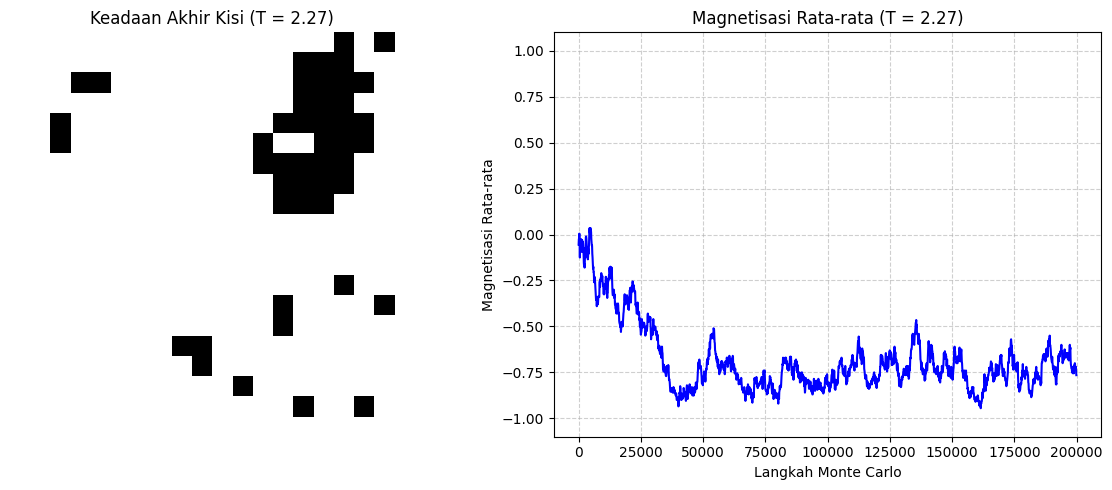

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. PARAMETER SISTEM
# ==========================================
N = 20                # Ukuran kisi 20x20
MCS = 200000          # Total langkah Monte Carlo
T = 2.27               # SUHU SISTEM

# Inisialisasi Hot Start (Spin acak -1 atau 1) untuk entropi maksimum
grid = np.random.choice([-1, 1], size=(N, N))

mag_history = []      # Array untuk menyimpan nilai magnetisasi

# ==========================================
# 2. ALGORITMA METROPOLIS
# ==========================================
for step in range(MCS):
    # Pilih koordinat kisi secara acak
    i = np.random.randint(0, N)
    j = np.random.randint(0, N)
    s = grid[i, j]

    # Hitung spin tetangga dengan Kondisi Batas Periodik (menggunakan modulo)
    tetangga = grid[(i+1)%N, j] + grid[(i-1)%N, j] + grid[i, (j+1)%N] + grid[i, (j-1)%N]

    # Hitung selisih energi lokal
    delta_E = 2 * s * tetangga

    # Kriteria penerimaan Metropolis
    if delta_E < 0:
        s *= -1 # Terima pembalikan spin
    elif np.random.rand() < np.exp(-delta_E / T):
        s *= -1 # Terima dengan probabilitas tertentu

    grid[i, j] = s # Update kisi

    # Catat rata-rata magnetisasi setiap 100 langkah
    if step % 100 == 0:
        mag_history.append(np.sum(grid) / (N**2))

# ==========================================
# 3. VISUALISASI HASIL
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Keadaan Akhir Kisi (Peta Warna Biner)
axes[0].imshow(grid, cmap='binary', vmin=-1, vmax=1)
axes[0].set_title(f"Keadaan Akhir Kisi (T = {T})")
axes[0].axis('off')

# Plot 2: Riwayat Magnetisasi
# Sumbu X: Langkah Monte Carlo (x100), Sumbu Y: Magnetisasi
axes[1].plot(range(0, MCS, 100), mag_history, color='blue', linewidth=1.5)
axes[1].set_title(f"Magnetisasi Rata-rata (T = {T})")
axes[1].set_xlabel("Langkah Monte Carlo")
axes[1].set_ylabel("Magnetisasi Rata-rata")
axes[1].set_ylim(-1.1, 1.1)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**ANALISIS**

Pada rentang suhu ini, sistem berada di sekitar titik suhu kritis teoretis atau Temperatur Curie (Tc ≈ 2.27). Di titik ini, terjadi kompetisi yang seimbang antara interaksi pertukaran (yang berusaha menyearahkan spin) dan fluktuasi termal (yang berusaha mengacak spin). Secara visual, sistem menunjukkan fluktuasi kritis di mana mulai terbentuk pola domain fraktal atau klaster-klaster spin dengan berbagai ukuran, yang menandai runtuhnya keteraturan jarak jauh (long-range order). Pada grafik magnetisasi, keadaan ini tercermin dari garis kurva yang tidak berkonvergen stabil di satu angka mutlak, melainkan menunjukkan fluktuasi yang signifikan akibat transisi dari fase teratur menuju fase acak.